In [2]:
# ============================================================
# LOAD LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import joblib
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

folder = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML"

print(os.listdir(folder))

['HB_STUDIE_kth.xlsx', 'Hb_Study_mardan.xlsx', 'Hemoglobinopathy_Final_Preprocessed.xlsx', '01_Data_Preprocessing.ipynb', ' 02_EDA.ipynb', 'Documentation.docx', 'external.xlsx', 'Hemoglobinopathy_Final_Preprocessed.csv', 'Hospital_LabelEncoder.pkl', 'Target_LabelEncoder.pkl', 'Gender_LabelEncoder.pkl', 'Hemoglobinopathy_XGBoost_Model.pkl', 'StandardScaler.pkl', '03_Machine_Learning_Model_Development.ipynb', 'EXternal_II.xlsx', '04_External_Data_Validation.ipynb']


In [4]:
# ============================================================
# DEFINE PROJECT PATH
# ============================================================
path = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML/"


In [5]:
# ============================================================
# LOAD TRAINED MODEL
# ============================================================

xgb_model = joblib.load(path + "Hemoglobinopathy_XGBoost_Model.pkl")

print("XGBoost Model Loaded Successfully")

XGBoost Model Loaded Successfully


In [6]:
# ============================================================
# LOAD LABEL ENCODERS
# ============================================================

from sklearn.preprocessing import LabelEncoder
import joblib

# Create Gender encoder manually
gender_encoder = LabelEncoder()
gender_encoder.fit(["Female", "Male"])

# Load saved encoders
hospital_encoder = joblib.load(path + "Hospital_LabelEncoder.pkl") # Use 'path' for consistency
target_encoder = joblib.load(path + "Target_LabelEncoder.pkl")     # Use 'path' for consistency

print("Label Encoders Loaded Successfully")

Label Encoders Loaded Successfully


In [7]:
# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================

import pandas as pd

external = pd.read_excel(path + "external.xlsx")

print("External Dataset Loaded Successfully")
print("Shape:", external.shape)

external.head()

External Dataset Loaded Successfully
Shape: (14, 14)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Interpretation
0,23-Years,Female,97.3,2.4,0.3,NaN,NaN,3.28,7.4,23.7,72.3,22.5,31.2,No evidence of Thalassemia and Hemoglobinopath...
1,21-Years,Female,97.0,2.9,0.1,NaN,NaN,4.55,13.0,37.3,82.1,28.6,34.9,No evidence of Thalassemia and Hemoglobinopath...
2,37,Male,93.9,5.5,0.6,NaN,NaN,5.85,13.6,45.2,77.2,23.3,30.2,Beta thalassemia Minor
3,37,Female,94.8,4.8,0.4,NaN,NaN,5.37,12.6,41.1,76.1,23.4,30.6,Beta thalassemia Minor
4,24,Female,96.8,3.0,0.2,NaN,NaN,5.34,15.3,42.3,79.2,28.7,36.3,Normal


In [8]:
# ============================================================
# PREPROCESS EXTERNAL DATA
# ============================================================

import numpy as np
import pandas as pd

# Rename target column
external.rename(columns={"Interpretation": "Results"}, inplace=True)

# -----------------------------
# Clean Age
# -----------------------------
external["Age"] = (
    external["Age"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

external["Age"] = pd.to_numeric(
    external["Age"],
    errors="coerce"
)

external["Age"] = external["Age"].fillna(
    external["Age"].median()
)

# -----------------------------
# Gender
# -----------------------------
external["Gender"] = (
    external["Gender"]
    .str.strip()
    .str.capitalize()
)

external["Gender"] = external["Gender"].map({
    "Female": 0,
    "Male": 1
})

# -----------------------------
# Hb-S and Hb-D
# -----------------------------
external["Hb-S"] = external["Hb-S"].fillna(0)
external["Hb-D"] = external["Hb-D"].fillna(0)

# -----------------------------
# Standardize diagnosis names
# -----------------------------
external["Results"] = external["Results"].replace({

    "No evidence of Thalassemia and Hemoglobinopathies detected": "Normal",
    "Beta thalassemia Minor": "Beta Thalassemia Minor",
    "Beta thalassemia major": "Beta Thalassemia Major",
    "Borderline Hb A2": "Borderline HbA2"

})

print("Preprocessing Completed")
external.head()

Preprocessing Completed


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results
0,23.0,0,97.3,2.4,0.3,0.0,0.0,3.28,7.4,23.7,72.3,22.5,31.2,Normal
1,21.0,0,97.0,2.9,0.1,0.0,0.0,4.55,13.0,37.3,82.1,28.6,34.9,Normal
2,37.0,1,93.9,5.5,0.6,0.0,0.0,5.85,13.6,45.2,77.2,23.3,30.2,Beta Thalassemia Minor
3,37.0,0,94.8,4.8,0.4,0.0,0.0,5.37,12.6,41.1,76.1,23.4,30.6,Beta Thalassemia Minor
4,24.0,0,96.8,3.0,0.2,0.0,0.0,5.34,15.3,42.3,79.2,28.7,36.3,Normal


In [9]:
print(xgb_model.n_features_in_)

13


In [138]:
# ============================================================
# PREPARE FEATURES
# ============================================================

# Removed the 'Hospital' column addition based on user feedback and model requirements.

feature_order = [
    "Age",
    "Gender",
    "Hb-A",
    "HB-A2",
    "Hb-F",
    "Hb-S",
    "Hb-D",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC"
    # Removed 'Hospital' from feature_order as it's not expected by the model.
]

X_external = external_II[feature_order] # Changed external to external_II

X_external.head()

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC
0,20.0,0,98.0,2.0,0.0,0.0,0.0,4.34,8.2,30.2,69.6,19.0,27.2
1,18.0,0,98.0,2.0,0.0,0.0,0.0,4.32,10.2,36.0,83.4,23.6,28.2
2,34.0,0,98.0,2.0,0.0,0.0,0.0,3.48,9.0,32.3,92.6,25.8,27.9
3,1.0,0,96.6,2.4,1.0,0.0,0.0,1.54,4.9,15.9,103.5,31.0,30.6
4,4.0,1,97.7,2.3,0.0,0.0,0.0,3.48,8.2,26.8,77.0,23.6,30.7


In [11]:
# ============================================================
# SCALE FEATURES
# ============================================================

# Load the scaler object
scaler = joblib.load(path + "StandardScaler.pkl")

# Identify features to be scaled (all features in X_external except 'Gender' and 'Hospital')
# Assuming 'Gender' and 'Hospital' were not part of the features used to fit the scaler
features_to_scale = [col for col in X_external.columns if col not in ['Gender', 'Hospital']]

# Apply scaling to these features
X_external_scaled_numeric = scaler.transform(X_external[features_to_scale])

# Create a DataFrame from the scaled numerical features
X_external_scaled = pd.DataFrame(X_external_scaled_numeric, columns=features_to_scale, index=X_external.index)

# Add the 'Gender' column back to the scaled DataFrame without scaling it
X_external_scaled['Gender'] = X_external['Gender']

# Ensure the order of columns in X_external_scaled matches the feature_order
# This is crucial for models like XGBoost that expect features in a specific order.
X_external_scaled = X_external_scaled[feature_order]

In [12]:
# ============================================================
# PREDICT
# ============================================================

predictions = xgb_model.predict(X_external_scaled)

probabilities = xgb_model.predict_proba(X_external_scaled)

In [139]:
# ============================================================
# TRUE LABELS
# ============================================================

y_true = target_encoder.transform(external_II["Results"]) # Changed external to external_II

In [14]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

y_pred = predictions # Assign the predictions from the model to y_pred

accuracy = accuracy_score(y_true, y_pred)
balanced = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print("="*60)
print("EXTERNAL VALIDATION RESULTS")
print("="*60)
print(f"Accuracy            : {accuracy:.4f}")
print(f"Balanced Accuracy   : {balanced:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"MCC                 : {mcc:.4f}")
print(f"Cohen Kappa         : {kappa:.4f}")

EXTERNAL VALIDATION RESULTS
Accuracy            : 1.0000
Balanced Accuracy   : 1.0000
Precision           : 1.0000
Recall              : 1.0000
F1-score            : 1.0000
MCC                 : 1.0000
Cohen Kappa         : 1.0000


In [15]:
# ============================================================
# CREATE FINAL RESULTS TABLE
# ============================================================

results = external.copy()

# Actual diagnosis
results["Actual"] = external["Results"]

# Predicted diagnosis (decode numeric labels)
results["Predicted"] = target_encoder.inverse_transform(y_pred)

# Correct prediction
results["Correct"] = results["Actual"] == results["Predicted"]

results

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results,Actual,Predicted,Correct
0,23.0,0,97.3,2.4,0.3,0.0,0.0,3.28,7.40,23.7,72.3,22.5,31.2,Normal,Normal,Normal,True
1,21.0,0,97.0,2.9,0.1,0.0,0.0,4.55,13.00,37.3,82.1,28.6,34.9,Normal,Normal,Normal,True
2,37.0,1,93.9,5.5,0.6,0.0,0.0,5.85,13.60,45.2,77.2,23.3,30.2,Beta Thalassemia Minor,Beta Thalassemia Minor,Beta Thalassemia Minor,True
3,37.0,0,94.8,4.8,0.4,0.0,0.0,5.37,12.60,41.1,76.1,23.4,30.6,Beta Thalassemia Minor,Beta Thalassemia Minor,Beta Thalassemia Minor,True
4,24.0,0,96.8,3.0,0.2,0.0,0.0,5.34,15.30,42.3,79.2,28.7,36.3,Normal,Normal,Normal,True
5,25.0,0,97.6,2.1,0.3,0.0,0.0,2.66,3.41,14.8,55.5,12.8,23.1,Normal,Normal,Normal,True
6,29.0,0,96.3,2.9,0.8,0.0,0.0,3.84,11.20,31.2,81.3,29.2,35.9,Normal,Normal,Normal,True
7,25.0,0,97.3,2.6,0.1,0.0,0.0,4.60,11.20,35.8,78.1,24.4,31.3,Normal,Normal,Normal,True
8,0.9,0,0.0,0.0,0.0,0.0,0.0,0.69,1.60,5.8,71.0,22.2,25.2,Beta Thalassemia Major,Beta Thalassemia Major,Beta Thalassemia Major,True
9,1.0,0,50.5,1.6,47.9,0.0,0.0,2.07,6.30,13.9,69.0,33.3,45.2,Beta Thalassemia Major,Beta Thalassemia Major,Beta Thalassemia Major,True


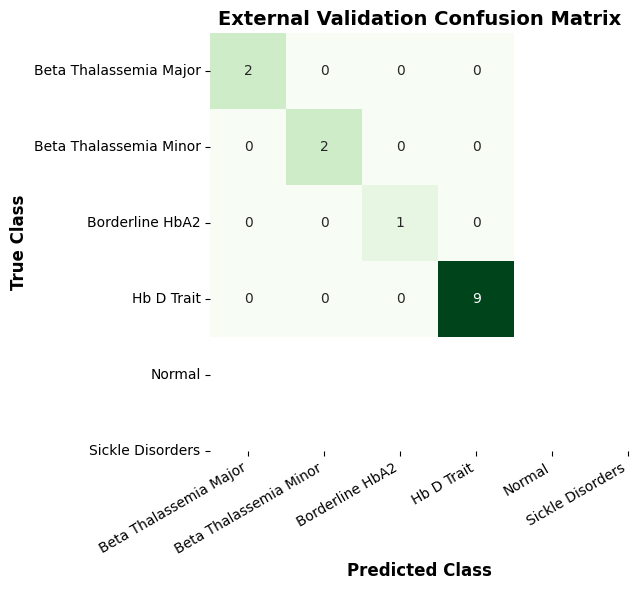

In [16]:
# ============================================================
# FIGURE 17
# EXTERNAL VALIDATION CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    square=True,
    cbar=False,
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted Class", fontsize=12, weight="bold")
plt.ylabel("True Class", fontsize=12, weight="bold")
plt.title(
    "External Validation Confusion Matrix",
    fontsize=14,
    weight="bold"
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Figure17_External_CM.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

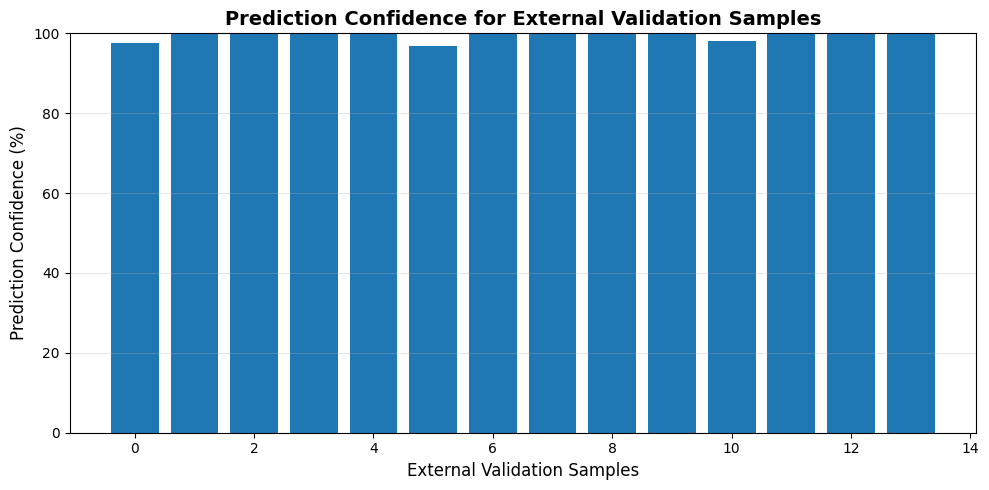

In [17]:
# ============================================================
# FIGURE 18
# EXTERNAL VALIDATION CONFIDENCE
# ============================================================

confidence = probabilities.max(axis=1) * 100

plt.figure(figsize=(10,5))

plt.bar(
    np.arange(len(confidence)),
    confidence
)

plt.ylim(0,100)

plt.xlabel("External Validation Samples", fontsize=12)
plt.ylabel("Prediction Confidence (%)", fontsize=12)
plt.title(
    "Prediction Confidence for External Validation Samples",
    fontsize=14,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure18_External_Confidence.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

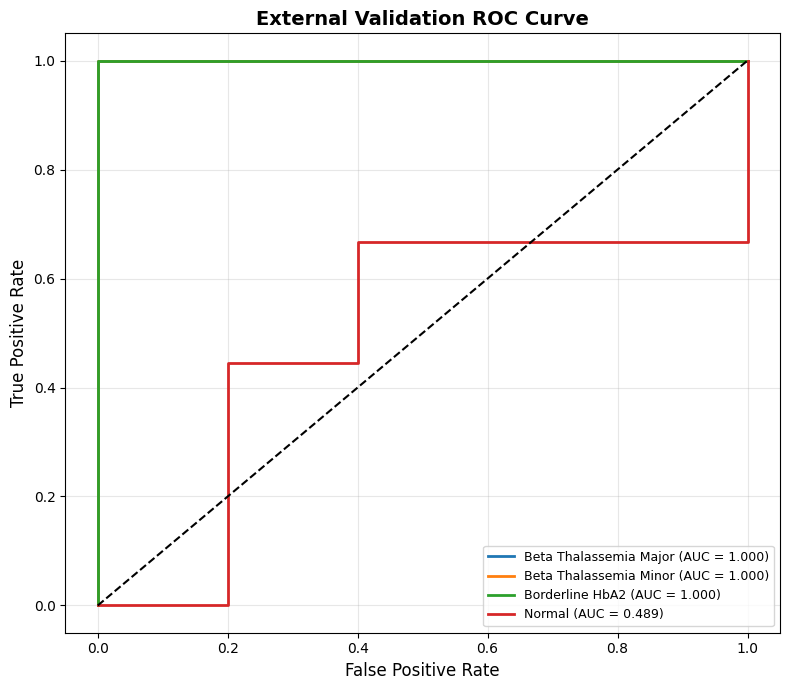

In [18]:
# ============================================================
# FIGURE 16
# EXTERNAL VALIDATION ROC CURVE
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Predicted probabilities from external validation
y_prob = xgb_model.predict_proba(X_external_scaled)

# True labels (encoded)
classes = np.unique(y_true)

# Binarize labels
y_external_bin = label_binarize(y_true, classes=classes)

plt.figure(figsize=(8,7))

colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]

# Plot ROC for each class
for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_external_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        color=colors[i],
        label=f"{target_encoder.classes_[classes[i]]} (AUC = {roc_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "External Validation ROC Curve",
    fontsize=14,
    weight="bold"
)

plt.legend(loc="lower right", fontsize=9)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure16_External_ROC.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [1]:
path = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML/"


In [92]:
# ============================================================
# LOAD TRAINED MODEL
# ============================================================

external_II = pd.read_excel(path + "EXternal_II.xlsx")


In [94]:
print(external_II.shape)

external_II.head()

(30, 14)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results
0,20.0,female,98.0,2.0,NaN,NaN,NaN,4.34,8.2,30.2,69.6,19.0,27.2,normal
1,18.0,female,98.0,2.0,NaN,NaN,NaN,4.32,10.2,36.0,83.4,23.6,28.2,normal
2,34.0,female,98.0,2.0,NaN,NaN,NaN,3.48,9.0,32.3,92.6,25.8,27.9,normal
3,1.0,female,96.6,2.4,1.0,NaN,NaN,1.54,4.9,15.9,103.5,31.0,30.6,normal
4,4.0,male,97.7,2.3,NaN,NaN,NaN,3.48,8.2,26.8,77.0,23.6,30.7,normal


In [95]:
external_II.columns.tolist()

['Age',
 'Gender',
 'Hb-A',
 'HB-A2',
 'Hb-F',
 'Hb-S',
 'Hb-D',
 'RBC',
 'HGB',
 'HCT',
 'MCV',
 'MCH',
 'MCHC',
 'Results']

In [97]:
external_II = external_II.fillna(0)

In [98]:
external_II.isnull().sum()

,0
Age,0
Gender,0
Hb-A,0
HB-A2,0
Hb-F,0
Hb-S,0
Hb-D,0
RBC,0
HGB,0
HCT,0


In [99]:
print(external_II["Results"].value_counts())
print(external_II["Results"].unique())

Results
normal                                      20
beta thalasemia minor                        9
p smear suggestive of hemoglobinopathies     1
Name: count, dtype: int64
['normal' 'beta thalasemia minor'
 'p smear suggestive of hemoglobinopathies']


In [100]:
external_II["Gender"].value_counts()

,count
Gender,
male,19
female,11


In [101]:
external_II["Gender"] = external_II["Gender"].str.strip().str.title()

In [102]:
external_II["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [103]:
external_II["Gender"] = gender_encoder.transform(external_II["Gender"])

In [104]:
external_II["Gender"].value_counts()

,count
Gender,
1,19
0,11


In [131]:
y_external = target_encoder.transform(external_II["Results"])

In [132]:
np.unique(y_external)

array([1, 2, 4])

In [107]:
X_external = external_II.drop("Results", axis=1)

In [108]:
print(X_external.shape)
print(X_external.columns.tolist())

(30, 13)
['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC']


In [109]:
train_df = pd.read_excel(path + "Hemoglobinopathy_Final_Preprocessed.xlsx")

In [110]:
X_train = train_df.drop("Results", axis=1)

In [133]:
label_map = {
    "normal": "Normal",
    "beta thalasemia minor": "Beta Thalassemia Minor",   # spelling correction
    "beta thalassemia minor": "Beta Thalassemia Minor",
    "p smear suggestive of hemoglobinopathies": "Borderline HbA2"   # TEMPORARY
}

external_II["Results"] = external_II["Results"].replace(label_map)

In [134]:
print(external_II["Results"].value_counts())

Results
Normal                    20
Beta Thalassemia Minor     9
Borderline HbA2            1
Name: count, dtype: int64


In [120]:
y_external = target_encoder.transform(external_II["Results"])

In [111]:
print(X_train.columns.tolist())
print(X_external.columns.tolist())

['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'Hospital']
['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC']


In [112]:
print(X_train.columns.equals(X_external.columns))

False


In [114]:
print(xgb_model.n_features_in_)

13


In [115]:
print(X_external.shape)

(30, 13)


In [116]:
print(xgb_model.get_booster().feature_names)

['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC']


In [121]:
X_external = external_II.drop("Results", axis=1)
y_external = target_encoder.transform(external_II["Results"])

In [122]:
X_external = external_II.drop("Results", axis=1)
y_external = target_encoder.transform(external_II["Results"])

In [144]:
y_pred = xgb_model.predict(X_external_scaled)
y_prob = xgb_model.predict_proba(X_external_scaled)

In [148]:
from sklearn.metrics import *

print("="*60)

print("EXTERNAL VALIDATION RESULTS")

print("="*60)

print("Accuracy          :", accuracy_score(y_external, y_pred))

print("Balanced Accuracy :", balanced_accuracy_score(y_external, y_pred))

print("Precision         :", precision_score(y_external, y_pred, average="weighted"))

print("Recall            :", recall_score(y_external, y_pred, average="weighted"))

print("F1-score          :", f1_score(y_external, y_pred, average="weighted"))

print("MCC               :", matthews_corrcoef(y_external, y_pred))

print("Cohen Kappa       :", cohen_kappa_score(y_external, y_pred))

print("\nClassification Report\n")

print(classification_report(

    y_external,

    y_pred,

    labels=np.arange(len(target_encoder.classes_)),

    target_names=target_encoder.classes_,

    zero_division=0

))

EXTERNAL VALIDATION RESULTS
Accuracy          : 0.9333333333333333
Balanced Accuracy : 0.6296296296296297
Precision         : 0.9333333333333333
Recall            : 0.9333333333333333
F1-score          : 0.9333333333333333
MCC               : 0.8588516746411483
Cohen Kappa       : 0.8568019093078759

Classification Report

                        precision    recall  f1-score   support

Beta Thalassemia Major       0.00      0.00      0.00         0
Beta Thalassemia Minor       0.89      0.89      0.89         9
       Borderline HbA2       0.00      0.00      0.00         1
            Hb D Trait       0.00      0.00      0.00         0
                Normal       1.00      1.00      1.00        20
      Sickle Disorders       0.00      0.00      0.00         0

              accuracy                           0.93        30
             macro avg       0.31      0.31      0.31        30
          weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [149]:
from sklearn.metrics import classification_report

print(classification_report(
    y_external,
    y_pred,
    labels=np.arange(len(target_encoder.classes_)),
    target_names=target_encoder.classes_,
    zero_division=0
))

results = external_II.copy()

results["Actual"] = target_encoder.inverse_transform(y_external)
results["Predicted"] = target_encoder.inverse_transform(y_pred)
results["Correct"] = results["Actual"] == results["Predicted"]

results[["Actual", "Predicted", "Correct"]]

                        precision    recall  f1-score   support

Beta Thalassemia Major       0.00      0.00      0.00         0
Beta Thalassemia Minor       0.89      0.89      0.89         9
       Borderline HbA2       0.00      0.00      0.00         1
            Hb D Trait       0.00      0.00      0.00         0
                Normal       1.00      1.00      1.00        20
      Sickle Disorders       0.00      0.00      0.00         0

              accuracy                           0.93        30
             macro avg       0.31      0.31      0.31        30
          weighted avg       0.93      0.93      0.93        30



,Actual,Predicted,Correct
0,Normal,Normal,True
1,Normal,Normal,True
2,Normal,Normal,True
3,Normal,Normal,True
4,Normal,Normal,True
5,Normal,Normal,True
6,Beta Thalassemia Minor,Beta Thalassemia Minor,True
7,Normal,Normal,True
8,Beta Thalassemia Minor,Beta Thalassemia Minor,True
9,Beta Thalassemia Minor,Beta Thalassemia Major,False


In [150]:
# Merge the feature matrices
X_external_all = np.vstack([X_external_scaled_1, X_external_scaled_2])

# Merge the true labels
y_external_all = np.concatenate([y_true_1, y_external])

# Predict on the combined cohort
y_pred_all = xgb_model.predict(X_external_all)
y_prob_all = xgb_model.predict_proba(X_external_all)

NameError: name 'X_external_scaled_1' is not defined

In [152]:
print("y_true:", y_true.shape)
print("predictions:", predictions.shape)

print("y_external:", y_external.shape)
print("y_pred:", y_pred.shape)

y_true: (30,)
predictions: (14,)
y_external: (30,)
y_pred: (30,)


In [153]:
y_true_all = np.concatenate([y_true, y_external])
y_pred_all = np.concatenate([predictions, y_pred])

In [154]:
print(external.shape)
external.head()

(14, 14)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results
0,23.0,0,97.3,2.4,0.3,0.0,0.0,3.28,7.4,23.7,72.3,22.5,31.2,Normal
1,21.0,0,97.0,2.9,0.1,0.0,0.0,4.55,13.0,37.3,82.1,28.6,34.9,Normal
2,37.0,1,93.9,5.5,0.6,0.0,0.0,5.85,13.6,45.2,77.2,23.3,30.2,Beta Thalassemia Minor
3,37.0,0,94.8,4.8,0.4,0.0,0.0,5.37,12.6,41.1,76.1,23.4,30.6,Beta Thalassemia Minor
4,24.0,0,96.8,3.0,0.2,0.0,0.0,5.34,15.3,42.3,79.2,28.7,36.3,Normal


In [155]:
print(external.columns.tolist())

['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'Results']


In [157]:
# First external dataset (14 patients)

X_external_1 = external.drop("Results", axis=1)

y_true_1 = target_encoder.transform(external["Results"])

In [160]:
# Numerical features only
X_num = external[features_to_scale]

# Scale them
X_num_scaled = scaler.transform(X_num)

# Convert back to DataFrame
X_num_scaled = pd.DataFrame(
    X_num_scaled,
    columns=features_to_scale,
    index=external.index
)

# Add Gender back
X_num_scaled["Gender"] = external["Gender"].values

# Reorder columns exactly as the model expects
X_external_scaled_1 = X_num_scaled[feature_order]

print(X_external_scaled_1.shape)
X_external_scaled_1.head()

(14, 13)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC
0,0.401609,0,0.894471,-0.529260,-0.543968,-0.359033,-0.480673,-0.124998,-0.489152,-0.758675,-0.006836,0.023963,0.345663
1,0.249239,0,0.885447,-0.141241,-0.550473,-0.359033,-0.480673,0.010533,0.983510,0.745659,0.736368,1.098535,1.435385
2,1.468200,1,0.792191,1.876457,-0.534211,-0.359033,-0.480673,0.149266,1.141295,1.619501,0.364766,0.164891,0.051144
3,1.468200,0,0.819265,1.333231,-0.540715,-0.359033,-0.480673,0.098041,0.878319,1.165988,0.281346,0.182507,0.168952
4,0.477794,0,0.879430,-0.063637,-0.547220,-0.359033,-0.480673,0.094840,1.588353,1.298723,0.516441,1.116151,1.847712


In [161]:
y_pred_1 = xgb_model.predict(X_external_scaled_1)

y_true_1 = target_encoder.transform(external["Results"])

In [162]:
print(len(y_true_1))
print(len(y_pred_1))

14
14


In [163]:
y_pred_1 = xgb_model.predict(X_external_scaled_1)

y_true_1 = target_encoder.transform(external["Results"])

In [164]:
# Merge true labels

y_true_all = np.concatenate([y_true_1, y_external])

# Merge predictions

y_pred_all = np.concatenate([y_pred_1, y_pred])

print(len(y_true_all), len(y_pred_all))

44 44


In [165]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

labels = np.arange(len(target_encoder.classes_))

print("="*60)
print("COMBINED EXTERNAL VALIDATION")
print("="*60)

print("Accuracy          :", accuracy_score(y_true_all, y_pred_all))
print("Balanced Accuracy :", balanced_accuracy_score(y_true_all, y_pred_all))
print("Precision         :", precision_score(y_true_all, y_pred_all, average="weighted"))
print("Recall            :", recall_score(y_true_all, y_pred_all, average="weighted"))
print("F1-score          :", f1_score(y_true_all, y_pred_all, average="weighted"))
print("MCC               :", matthews_corrcoef(y_true_all, y_pred_all))
print("Cohen Kappa       :", cohen_kappa_score(y_true_all, y_pred_all))

print("\nClassification Report\n")

print(classification_report(
    y_true_all,
    y_pred_all,
    labels=labels,
    target_names=target_encoder.classes_,
    zero_division=0
))

COMBINED EXTERNAL VALIDATION
Accuracy          : 0.9545454545454546
Balanced Accuracy : 0.8522727272727273
Precision         : 0.9621212121212122
Recall            : 0.9545454545454546
F1-score          : 0.9530303030303031
MCC               : 0.9098450481061464
Cohen Kappa       : 0.9089026915113871

Classification Report

                        precision    recall  f1-score   support

Beta Thalassemia Major       0.67      1.00      0.80         2
Beta Thalassemia Minor       0.91      0.91      0.91        11
       Borderline HbA2       1.00      0.50      0.67         2
            Hb D Trait       0.00      0.00      0.00         0
                Normal       1.00      1.00      1.00        29
      Sickle Disorders       0.00      0.00      0.00         0

              accuracy                           0.95        44
             macro avg       0.60      0.57      0.56        44
          weighted avg       0.96      0.95      0.95        44



In [166]:
cm = confusion_matrix(y_true_all, y_pred_all, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=target_encoder.classes_,
    columns=target_encoder.classes_
)

cm_df

,Beta Thalassemia Major,Beta Thalassemia Minor,Borderline HbA2,Hb D Trait,Normal,Sickle Disorders
Beta Thalassemia Major,2,0,0,0,0,0
Beta Thalassemia Minor,1,10,0,0,0,0
Borderline HbA2,0,1,1,0,0,0
Hb D Trait,0,0,0,0,0,0
Normal,0,0,0,0,29,0
Sickle Disorders,0,0,0,0,0,0


In [167]:
combined_results = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(y_true_all),
    "Predicted": target_encoder.inverse_transform(y_pred_all)
})

combined_results["Correct"] = (
    combined_results["Actual"] ==
    combined_results["Predicted"]
)

combined_results

,Actual,Predicted,Correct
0,Normal,Normal,True
1,Normal,Normal,True
2,Beta Thalassemia Minor,Beta Thalassemia Minor,True
3,Beta Thalassemia Minor,Beta Thalassemia Minor,True
4,Normal,Normal,True
5,Normal,Normal,True
6,Normal,Normal,True
7,Normal,Normal,True
8,Beta Thalassemia Major,Beta Thalassemia Major,True
9,Beta Thalassemia Major,Beta Thalassemia Major,True


In [168]:
combined_results[combined_results["Correct"] == False]

,Actual,Predicted,Correct
23,Beta Thalassemia Minor,Beta Thalassemia Major,False
29,Borderline HbA2,Beta Thalassemia Minor,False


In [170]:
y_prob_all = np.concatenate([probabilities, y_prob])

combined_results["Confidence"] = np.max(y_prob_all, axis=1)

combined_results[combined_results["Correct"] == False]

,Actual,Predicted,Correct,Confidence
23,Beta Thalassemia Minor,Beta Thalassemia Major,False,0.987909
29,Borderline HbA2,Beta Thalassemia Minor,False,0.728632


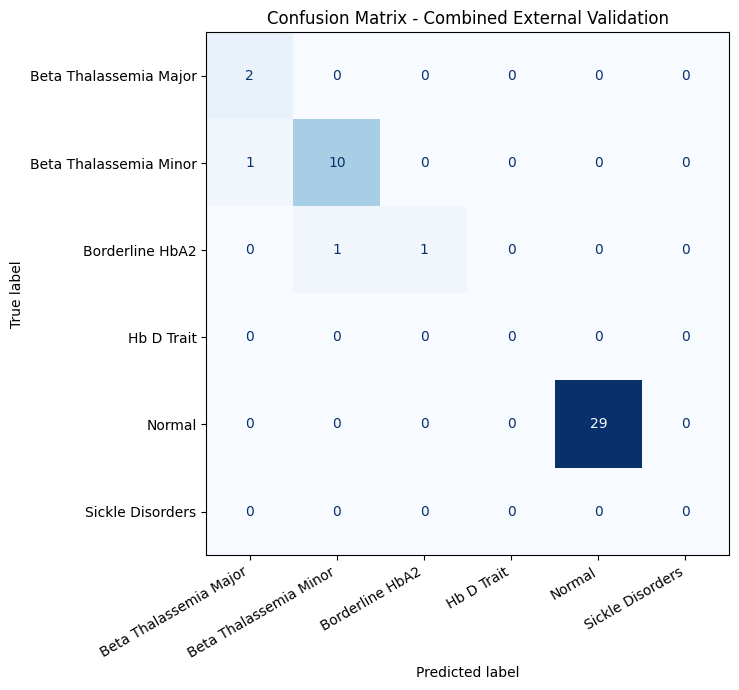

In [171]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = np.arange(len(target_encoder.classes_))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8,7))
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.xticks(rotation=30, ha='right')
plt.title("Confusion Matrix - Combined External Validation")
plt.tight_layout()
plt.show()

Skipping Hb D Trait (only 0 positive sample(s))
Skipping Sickle Disorders (only 0 positive sample(s))


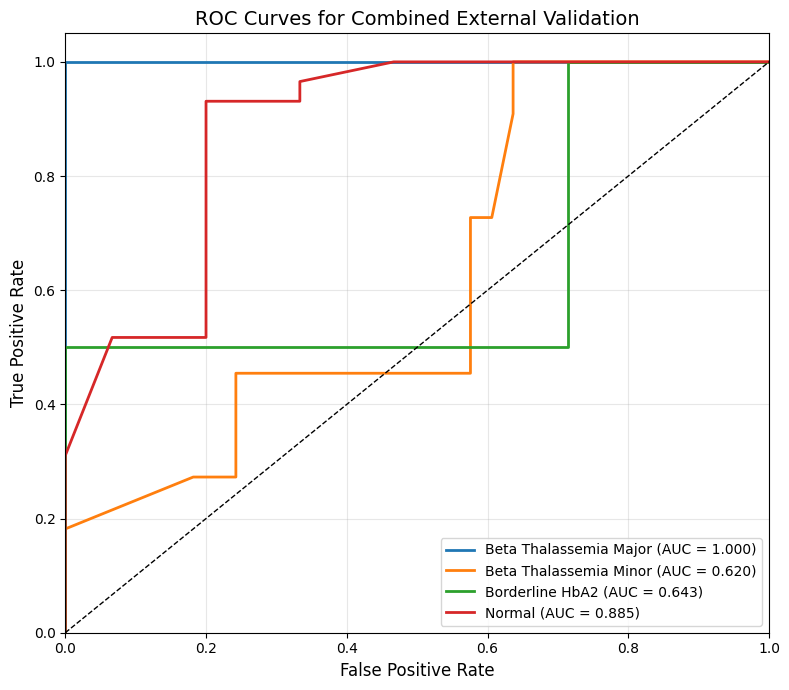

In [177]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Classes in the model
labels = np.arange(len(target_encoder.classes_))

# Binarize true labels
y_true_bin = label_binarize(y_true_all, classes=labels)

# Create figure
plt.figure(figsize=(8, 7))

# Plot ROC only for classes with at least 2 positive samples
for i in labels:

    # Number of positive samples for this class
    n_positive = np.sum(y_true_bin[:, i])

    # Skip classes with insufficient samples
    if n_positive < 2:
        print(f"Skipping {target_encoder.classes_[i]} (only {n_positive} positive sample(s))")
        continue

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{target_encoder.classes_[i]} (AUC = {roc_auc:.3f})"
    )

# Reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Formatting
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Combined External Validation", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

In [173]:
metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Matthews Correlation Coefficient",
        "Cohen's Kappa"
    ],

    "Value":[
        accuracy_score(y_true_all,y_pred_all),
        balanced_accuracy_score(y_true_all,y_pred_all),
        precision_score(y_true_all,y_pred_all,average="weighted"),
        recall_score(y_true_all,y_pred_all,average="weighted"),
        f1_score(y_true_all,y_pred_all,average="weighted"),
        matthews_corrcoef(y_true_all,y_pred_all),
        cohen_kappa_score(y_true_all,y_pred_all)
    ]

})

metrics_df["Value"] = metrics_df["Value"].round(4)

metrics_df

,Metric,Value
0,Accuracy,0.9545
1,Balanced Accuracy,0.8523
2,Precision,0.9621
3,Recall,0.9545
4,F1-score,0.9530
5,Matthews Correlation Coefficient,0.9098
6,Cohen's Kappa,0.9089


In [174]:
report = classification_report(
    y_true_all,
    y_pred_all,
    labels=np.arange(len(target_encoder.classes_)),
    target_names=target_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

report_df.round(3)

,precision,recall,f1-score,support
Beta Thalassemia Major,0.667,1.000,0.800,2.000
Beta Thalassemia Minor,0.909,0.909,0.909,11.000
Borderline HbA2,1.000,0.500,0.667,2.000
Hb D Trait,0.000,0.000,0.000,0.000
Normal,1.000,1.000,1.000,29.000
Sickle Disorders,0.000,0.000,0.000,0.000
accuracy,0.955,0.955,0.955,0.955
macro avg,0.596,0.568,0.563,44.000
weighted avg,0.962,0.955,0.953,44.000


In [175]:
combined_results["Confidence"] = np.max(y_prob_all,axis=1)

combined_results.sort_values(
    "Confidence",
    ascending=False
)

,Actual,Predicted,Correct,Confidence
12,Normal,Normal,True,0.999898
2,Beta Thalassemia Minor,Beta Thalassemia Minor,True,0.999760
13,Normal,Normal,True,0.999654
8,Beta Thalassemia Major,Beta Thalassemia Major,True,0.999602
1,Normal,Normal,True,0.999547
3,Beta Thalassemia Minor,Beta Thalassemia Minor,True,0.999525
11,Normal,Normal,True,0.999468
6,Normal,Normal,True,0.999141
9,Beta Thalassemia Major,Beta Thalassemia Major,True,0.999034
4,Normal,Normal,True,0.998828
